In [6]:
import pandas as pd
import matplotlib.pylab as plt
import matplotlib.dates as mdates

path = "../data/raw/ACLED Data_2026-06-24.csv"

print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
rawData = pd.read_csv(path, low_memory=False)

print(f"Shape: {rawData.shape[0]:,} rows x {rawData.shape[1]:,} columns")
rawData.head()

Shape: 1,087,171 rows x 31 columns


,event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,...,location,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp
0,EGY8633,2018-01-01,2018,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (Egypt),NaN,Political militia,...,Al Umraniyah,30.0024,31.2019,1,Egypt Independent,National,Unidentified militants attacked a liquor shop ...,2,NaN,1618529456
1,IRQ19369,2018-01-01,2018,1,Political violence,Battles,Armed clash,PKK: Kurdistan Workers Party,NaN,Rebel group,...,Soran,36.6543,44.5377,2,People's Defense Forces,Other,"HPG reported that on January 1, PKK attacked T...",0,NaN,1618558319
2,IRN291,2018-01-01,2018,1,Political violence,Battles,Armed clash,Unidentified Armed Group (Iran),NaN,Political militia,...,Najafabad,32.6344,51.3668,1,AFP,International,A policeman was shot dead in Iran on Monday in...,1,NaN,1561470034
3,YEM7879,2018-01-01,2018,1,Political violence,Explosions/Remote violence,Air/drone strike,Operation Restoring Hope,NaN,External/Other forces,...,Al Khafji,16.9861,43.6798,2,Yemen News Agency SABA,National,Three airstrikes were Al-anad area of Sahar di...,0,NaN,1561471478
4,IRN290,2018-01-01,2018,1,Demonstrations,Protests,Peaceful protest,Protesters (Iran),Labor Group (Iran),Protesters,...,Ravasan,38.0456,46.2005,1,Iranian Labour News Agency,National,Workers of Tabriz Industrial Machines company ...,0,NaN,1618556715


In [9]:
print(rawData.dtypes)

event_id_cnty             str
event_date                str
year                    int64
time_precision          int64
disorder_type             str
event_type                str
sub_event_type            str
actor1                    str
assoc_actor_1             str
inter1                    str
actor2                    str
assoc_actor_2             str
inter2                    str
interaction               str
civilian_targeting        str
iso                     int64
region                    str
country                   str
admin1                    str
admin2                    str
admin3                    str
location                  str
latitude              float64
longitude             float64
geo_precision           int64
source                    str
source_scale              str
notes                     str
fatalities              int64
tags                      str
timestamp               int64
dtype: object


In [10]:
print(rawData.isnull().sum())

event_id_cnty              0
event_date                 0
year                       0
time_precision             0
disorder_type              0
event_type                 0
sub_event_type             0
actor1                     0
assoc_actor_1         735244
inter1                     0
actor2                578297
assoc_actor_2         989723
inter2                578297
interaction                0
civilian_targeting    986177
iso                        0
region                     0
country                    0
admin1                     8
admin2                 38695
admin3                569228
location                   0
latitude                   0
longitude                  0
geo_precision              0
source                     0
source_scale               0
notes                      0
fatalities                 0
tags                  679833
timestamp                  0
dtype: int64


In [11]:
rawData['event_date'] = pd.to_datetime(rawData['event_date'])

print(f'Earliest event date: {rawData["event_date"].min()}')
print(f'Latest event date: {rawData["event_date"].max()}')

Earliest event date: 2018-01-01 00:00:00
Latest event date: 2025-06-24 00:00:00


In [12]:
eventCounts = rawData['event_type'].value_counts()
print(eventCounts)
print(f'Total events: {eventCounts.sum():,}')

event_type
Protests                      366155
Explosions/Remote violence    354996
Battles                       194587
Strategic developments         79041
Riots                          48706
Violence against civilians     43686
Name: count, dtype: int64
Total events: 1,087,171


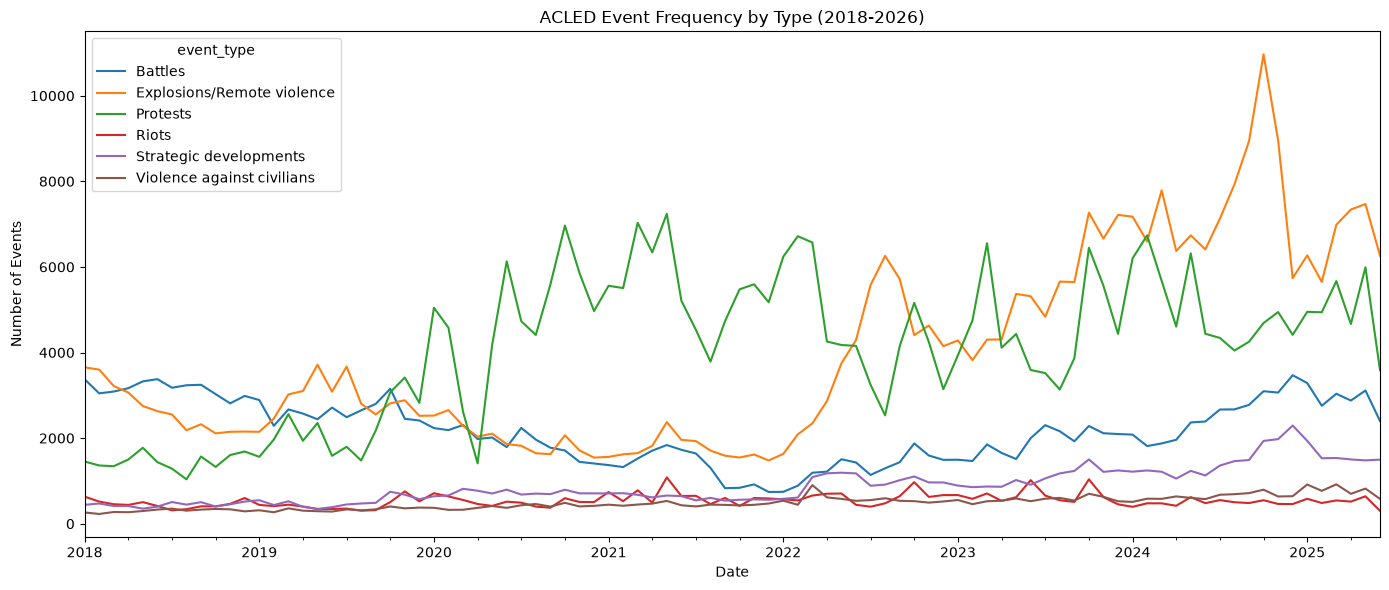

In [15]:
monthly = rawData.groupby([pd.Grouper(key='event_date', freq='ME'), 'event_type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
monthly.plot(ax = ax)

ax.set_title('ACLED Event Frequency by Type (2018-2026)')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Events')
plt.tight_layout()
plt.show()

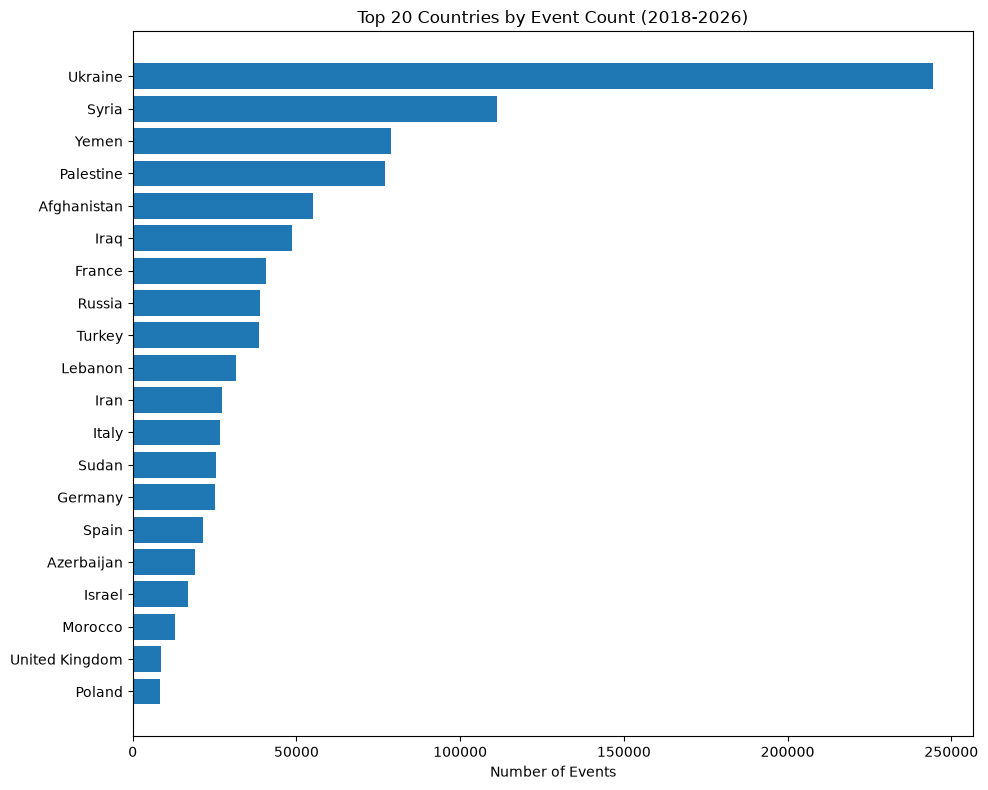

In [ ]:
topCountries = rawData['country'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(topCountries.index, topCountries.values)
ax.invert_yaxis()
ax.set_xlabel('Number of Events')
ax.set_title('Top 20 Countries by Event Count (2018-2026)')
plt.tight_layout()
plt.show()